In [1]:
import pandas as pd

df = pd.read_csv("FINAL.csv")

print(df.shape)
print(df.head())
print(df.info())

(54908, 17)
   ClientId   Age  Gender            Occupation  ClientType  \
0       875  59.0     1.0                FARMER           0   
1       876  55.0     1.0                FARMER           0   
2       894  46.0     1.0  BUSINESSMEN / TRADER           0   
3       943  51.0     1.0              SALARIED           0   
4       944  45.0     2.0               DOCTORS           0   

   SeniorCitizenFlag  RiskCategoryId  total_transactions  total_amount  \
0                0.0             9.0                   2         133.0   
1                0.0             9.0                   3       15602.4   
2                0.0             4.0                  47      441518.4   
3                0.0             2.0                 184      569835.4   
4                0.0             8.0                   1          46.0   

   avg_transaction  max_transaction  min_transaction  recency_days  \
0          66.5000            110.0             23.0           246   
1        5200.8000      

In [2]:
nulls = pd.DataFrame({
    "Null_Count": df.isnull().sum(),
    "Null_Percent": round(df.isnull().mean()*100,2)
})

print(nulls.sort_values("Null_Percent", ascending=False))

                    Null_Count  Null_Percent
Occupation               17782         32.39
amount_var               15987         29.12
amount_std               15987         29.12
Gender                    3603          6.56
Age                       3597          6.55
SeniorCitizenFlag         1090          1.99
ClientId                     0          0.00
ClientType                   0          0.00
RiskCategoryId               1          0.00
total_amount                 0          0.00
total_transactions           0          0.00
avg_transaction              0          0.00
max_transaction              0          0.00
recency_days                 0          0.00
min_transaction              0          0.00
active_days                  0          0.00
activity_span                0          0.00


In [3]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate ClientId:", df["ClientId"].duplicated().sum())

Duplicate rows: 0
Duplicate ClientId: 0


In [4]:
print(df.dtypes)

ClientId                int64
Age                   float64
Gender                float64
Occupation                str
ClientType              int64
SeniorCitizenFlag     float64
RiskCategoryId        float64
total_transactions      int64
total_amount          float64
avg_transaction       float64
max_transaction       float64
min_transaction       float64
recency_days            int64
activity_span           int64
active_days             int64
amount_std            float64
amount_var            float64
dtype: object


In [5]:
print(df.describe(include='all'))

            ClientId           Age        Gender Occupation    ClientType  \
count   5.490800e+04  51311.000000  51305.000000      37126  54908.000000   
unique           NaN           NaN           NaN         53           NaN   
top              NaN           NaN           NaN     FARMER           NaN   
freq             NaN           NaN           NaN      14329           NaN   
mean    7.023427e+05     50.826626      1.307943        NaN      0.065692   
std     6.477198e+05     15.539412      0.461647        NaN      0.247745   
min     6.470000e+02      8.000000      1.000000        NaN      0.000000   
25%     2.877212e+05     39.000000      1.000000        NaN      0.000000   
50%     7.153015e+05     50.000000      1.000000        NaN      0.000000   
75%     7.448835e+05     62.000000      2.000000        NaN      0.000000   
max     2.524257e+06    198.000000      2.000000        NaN      1.000000   

        SeniorCitizenFlag  RiskCategoryId  total_transactions  total_amount

In [6]:
print(
    (
        df["max_transaction"] < df["avg_transaction"]
    ).sum()
)

print(
    (
        df["avg_transaction"] < df["min_transaction"]
    ).sum()
)

0
0


In [7]:
corr = df.select_dtypes(include='number').corr()

print(corr["amount_std"].sort_values(ascending=False))

amount_std            1.000000
avg_transaction       0.932407
max_transaction       0.807497
amount_var            0.700726
total_amount          0.271961
ClientType            0.184220
ClientId              0.099067
activity_span         0.063501
Gender                0.028003
RiskCategoryId        0.027216
min_transaction       0.020254
active_days          -0.005982
total_transactions   -0.007906
Age                  -0.012320
SeniorCitizenFlag    -0.041517
recency_days         -0.113130
Name: amount_std, dtype: float64


In [10]:
import pandas as pd

df = pd.read_csv("FINAL.csv")

# Age
df["Age"] = df["Age"].fillna(df["Age"].median())

# Gender
df["Gender"] = df["Gender"].fillna(0)

# Occupation
df["Occupation"] = df["Occupation"].fillna("UNKNOWN")

# Senior Citizen
df["SeniorCitizenFlag"] = df["SeniorCitizenFlag"].fillna(
    df["SeniorCitizenFlag"].mode()[0]
)

# Risk Category
df["RiskCategoryId"] = df["RiskCategoryId"].fillna(
    df["RiskCategoryId"].mode()[0]
)

# Std
df["amount_std"] = df["amount_std"].fillna(0)

# Drop variance
df = df.drop(columns=["amount_var"])

# Add feature
df["transactions_per_day"] = (
    df["total_transactions"] /
    df["active_days"].replace(0, 1)
)

df.to_csv("FINAL_CLEANED.csv", index=False)

print(df.isnull().sum())

ClientId                0
Age                     0
Gender                  0
Occupation              0
ClientType              0
SeniorCitizenFlag       0
RiskCategoryId          0
total_transactions      0
total_amount            0
avg_transaction         0
max_transaction         0
min_transaction         0
recency_days            0
activity_span           0
active_days             0
amount_std              0
transactions_per_day    0
dtype: int64


In [11]:
df.loc[
    (df["Age"] < 18) |
    (df["Age"] > 100),
    "Age"
] = pd.NA

df["Age"] = df["Age"].fillna(df["Age"].median())

In [13]:
df = pd.read_csv("FINAL_CLEANED.csv")

print(df.shape)
print(df.isnull().sum())

(54908, 17)
ClientId                0
Age                     0
Gender                  0
Occupation              0
ClientType              0
SeniorCitizenFlag       0
RiskCategoryId          0
total_transactions      0
total_amount            0
avg_transaction         0
max_transaction         0
min_transaction         0
recency_days            0
activity_span           0
active_days             0
amount_std              0
transactions_per_day    0
dtype: int64


In [14]:
print(df["Age"].describe())

count    54908.000000
mean        50.772474
std         15.023183
min          8.000000
25%         40.000000
50%         50.000000
75%         61.000000
max        198.000000
Name: Age, dtype: float64


In [15]:
import numpy as np

# Invalid ages
df.loc[
    (df["Age"] < 18) |
    (df["Age"] > 100),
    "Age"
] = np.nan

# Fill with median
df["Age"] = df["Age"].fillna(df["Age"].median())

print(df["Age"].describe())

count    54908.000000
mean        50.774514
std         14.914861
min         18.000000
25%         40.000000
50%         50.000000
75%         61.000000
max        100.000000
Name: Age, dtype: float64


In [16]:
print(df["Age"].describe())

count    54908.000000
mean        50.774514
std         14.914861
min         18.000000
25%         40.000000
50%         50.000000
75%         61.000000
max        100.000000
Name: Age, dtype: float64


In [17]:
from sklearn.preprocessing import LabelEncoder
import joblib

occupation_encoder = LabelEncoder()

df["Occupation"] = occupation_encoder.fit_transform(
    df["Occupation"]
)

joblib.dump(
    occupation_encoder,
    "occupation_encoder.pkl"
)

['occupation_encoder.pkl']

In [18]:
X = df.drop(columns=["ClientId"])

In [19]:
import numpy as np

log_cols = [
    "total_amount",
    "avg_transaction",
    "max_transaction",
    "amount_std",
    "transactions_per_day"
]

for col in log_cols:
    X[col] = np.log1p(X[col])

In [20]:
import joblib

feature_order = X.columns.tolist()

joblib.dump(
    feature_order,
    "feature_order.pkl"
)

['feature_order.pkl']

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

[603891.6995769771, 516668.8987559804, 460345.51178829215, 405347.96494935575, 375173.86847222154, 344258.2261285271, 303070.5888969086, 284474.2929442143, 265672.8557038025]


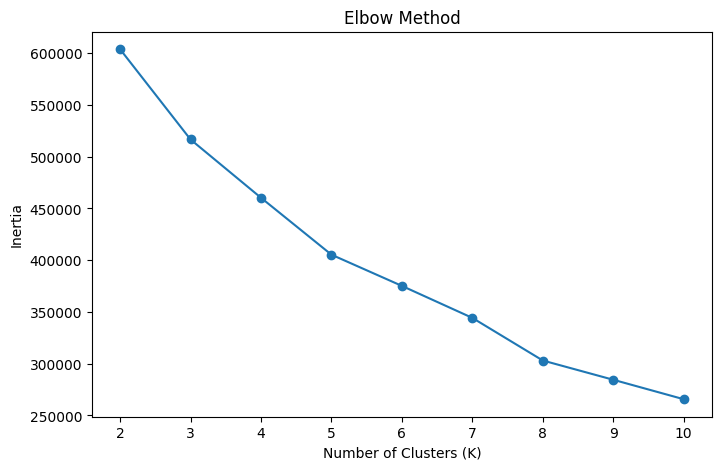

In [23]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

print(inertia)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [24]:
from sklearn.cluster import KMeans
import numpy as np
import joblib

# -------------------
# TRAIN FINAL MODEL
# -------------------
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# -------------------
# DISTANCES
# -------------------
distances = kmeans.transform(X_scaled)

min_distances = np.min(distances, axis=1)

# -------------------
# THRESHOLD
# -------------------
threshold = np.percentile(
    min_distances,
    95
)

print("Threshold:", threshold)

# -------------------
# SAVE
# -------------------
joblib.dump(
    kmeans,
    "kmeans.pkl"
)

joblib.dump(
    threshold,
    "threshold.pkl"
)

print("Model Saved Successfully")

Threshold: 3.8575221275344607
Model Saved Successfully


In [26]:
import pandas as pd

print(
    pd.Series(min_distances).describe()
)

count    54908.000000
mean         2.319200
std          1.415507
min          0.731283
25%          1.687734
50%          2.076647
75%          2.647224
max        137.147767
dtype: float64


In [27]:
import pandas as pd

cluster_counts = pd.Series(clusters).value_counts()

print(cluster_counts)

0    19945
3    18395
2    10030
1     3367
4     3171
Name: count, dtype: int64


In [28]:
print(feature_order)

['Age', 'Gender', 'Occupation', 'ClientType', 'SeniorCitizenFlag', 'RiskCategoryId', 'total_transactions', 'total_amount', 'avg_transaction', 'max_transaction', 'min_transaction', 'recency_days', 'activity_span', 'active_days', 'amount_std', 'transactions_per_day']


In [29]:
import pandas as pd

cluster_profile = pd.DataFrame(X)

cluster_profile["cluster"] = clusters

summary = cluster_profile.groupby("cluster").mean()

print(summary)

               Age    Gender  Occupation  ClientType  SeniorCitizenFlag  \
cluster                                                                   
0        44.293407  1.299875   25.999298    0.001354           0.000000   
1        39.573211  1.048411   37.408672    0.121770           0.029106   
2        70.806381  1.269392   23.033300    0.000199           0.999900   
3        49.064963  1.354064   32.594292    0.000000           0.221310   
4        49.988647  0.002523   49.958057    0.999054           0.001892   

         RiskCategoryId  total_transactions  total_amount  avg_transaction  \
cluster                                                                      
0              5.112259            1.881775      3.761890         3.322089   
1              5.122958          792.899614     13.940203         7.491030   
2              5.961515            2.252841      4.639997         4.045666   
3              5.185268           29.027073     11.787249         9.248380   
4     

In [30]:
import pandas as pd
import numpy as np

distances = kmeans.transform(X_scaled)

min_distances = np.min(distances, axis=1)

anomalies = min_distances > threshold

print("Anomalies:", anomalies.sum())
print("Percentage:", round(anomalies.mean()*100,2), "%")

Anomalies: 2746
Percentage: 5.0 %


In [31]:
temp = df.copy()

temp["distance"] = min_distances
temp["cluster"] = clusters

print(
    temp.sort_values(
        "distance",
        ascending=False
    ).head(20)
)

       ClientId   Age  Gender  Occupation  ClientType  SeniorCitizenFlag  \
42501    733617  26.0     1.0           7           0                0.0   
32038    716178  50.0     0.0          50           1                0.0   
53168    743331  45.0     2.0          22           0                0.0   
45740    753895  50.0     0.0          50           1                0.0   
20416    483808  50.0     0.0          50           1                0.0   
22611    709849  50.0     0.0          50           1                0.0   
32732    752167  50.0     0.0          50           1                0.0   
45130    754510  50.0     0.0          50           1                0.0   
46920   2524116  41.0     1.0          50           0                0.0   
33989    751011  50.0     0.0          50           1                0.0   
36055    736011  43.0     2.0           7           0                0.0   
49001    749324  34.0     1.0           7           0                0.0   
34102    720